# **Projeto Final Harve – Kaggle House Prices**
Previsão de Preços de Imóveis com Machine Learning

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###**1. Objetivo do Projeto:**
Este projeto tem como objetivo desenvolver um modelo de machine learning para prever o preço final de venda de imóveis (SalePrice) com base em características descritivas fornecidas no dataset House Prices: Advanced Regression Techniques do Kaggle. Foram seguidas as etapas de análise exploratória, tratamento de dados, engenharia de atributos, criação de variáveis dummy, modelagem e validação.

###**2. Importação das Bibliotecas**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

###**3. Carregamento dos Dados**

Os arquivos train.csv e test.csv foram carregados. O conjunto de treino possui 1460 linhas e 81 colunas, enquanto o teste possui 1459 linhas e 80 colunas (a coluna SalePrice está ausente no teste, pois é o alvo a ser previsto).

In [7]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

print(f"Treino: {df_train.shape}")
print(f"Teste: {df_test.shape}")

Treino: (1460, 81)
Teste: (1459, 80)


# **Questão 1 – Histograma da Variável SalePrice**

###**Objetivo**
Visualizar a distribuição dos preços de venda para identificar assimetrias e possíveis outliers.

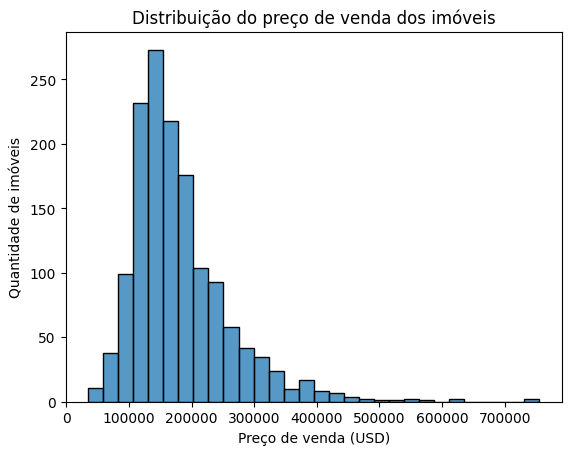

In [8]:
sns.histplot(data=df_train, x='SalePrice', bins=30)
plt.title('Distribuição do preço de venda dos imóveis')
plt.xlabel('Preço de venda (USD)')
plt.ylabel('Quantidade de imóveis')
plt.show()

### **Análise e Interpretação**

O histograma revela uma distribuição assimétrica à direita (*right-skewed*), com maior concentração dos imóveis em faixas de preço mais baixas, aproximadamente entre US\$ 100 mil e US\$ 200 mil, e uma cauda longa em direção aos valores mais elevados, chegando a US\$ 755 mil.

Essa distribuição indica a presença de imóveis com preços significativamente superiores à maior parte das observações, que deverão ser investigados posteriormente na análise de outliers.

Além disso, a mediana de US\$ 163 mil é inferior à média de aproximadamente US\$ 180,9 mil, o que reforça a influência dos valores mais elevados sobre a média dos preços.

# **Questão 2 – Identificação de Outliers nas Variáveis Numéricas**

###**Objetivo**
Detectar valores atípicos (outliers) nas variáveis numéricas utilizando boxplots e a regra do IQR (Intervalo Interquartil).

###**Metodologia**
* Seleção apenas das colunas numéricas (select_dtypes).
* Remoção da coluna Id.
* Geração de boxplots para identificação visual.
* Cálculo do IQR e contagem de pontos fora dos limites Q1 - 1.5*IQR e Q3 + 1.5*IQR.

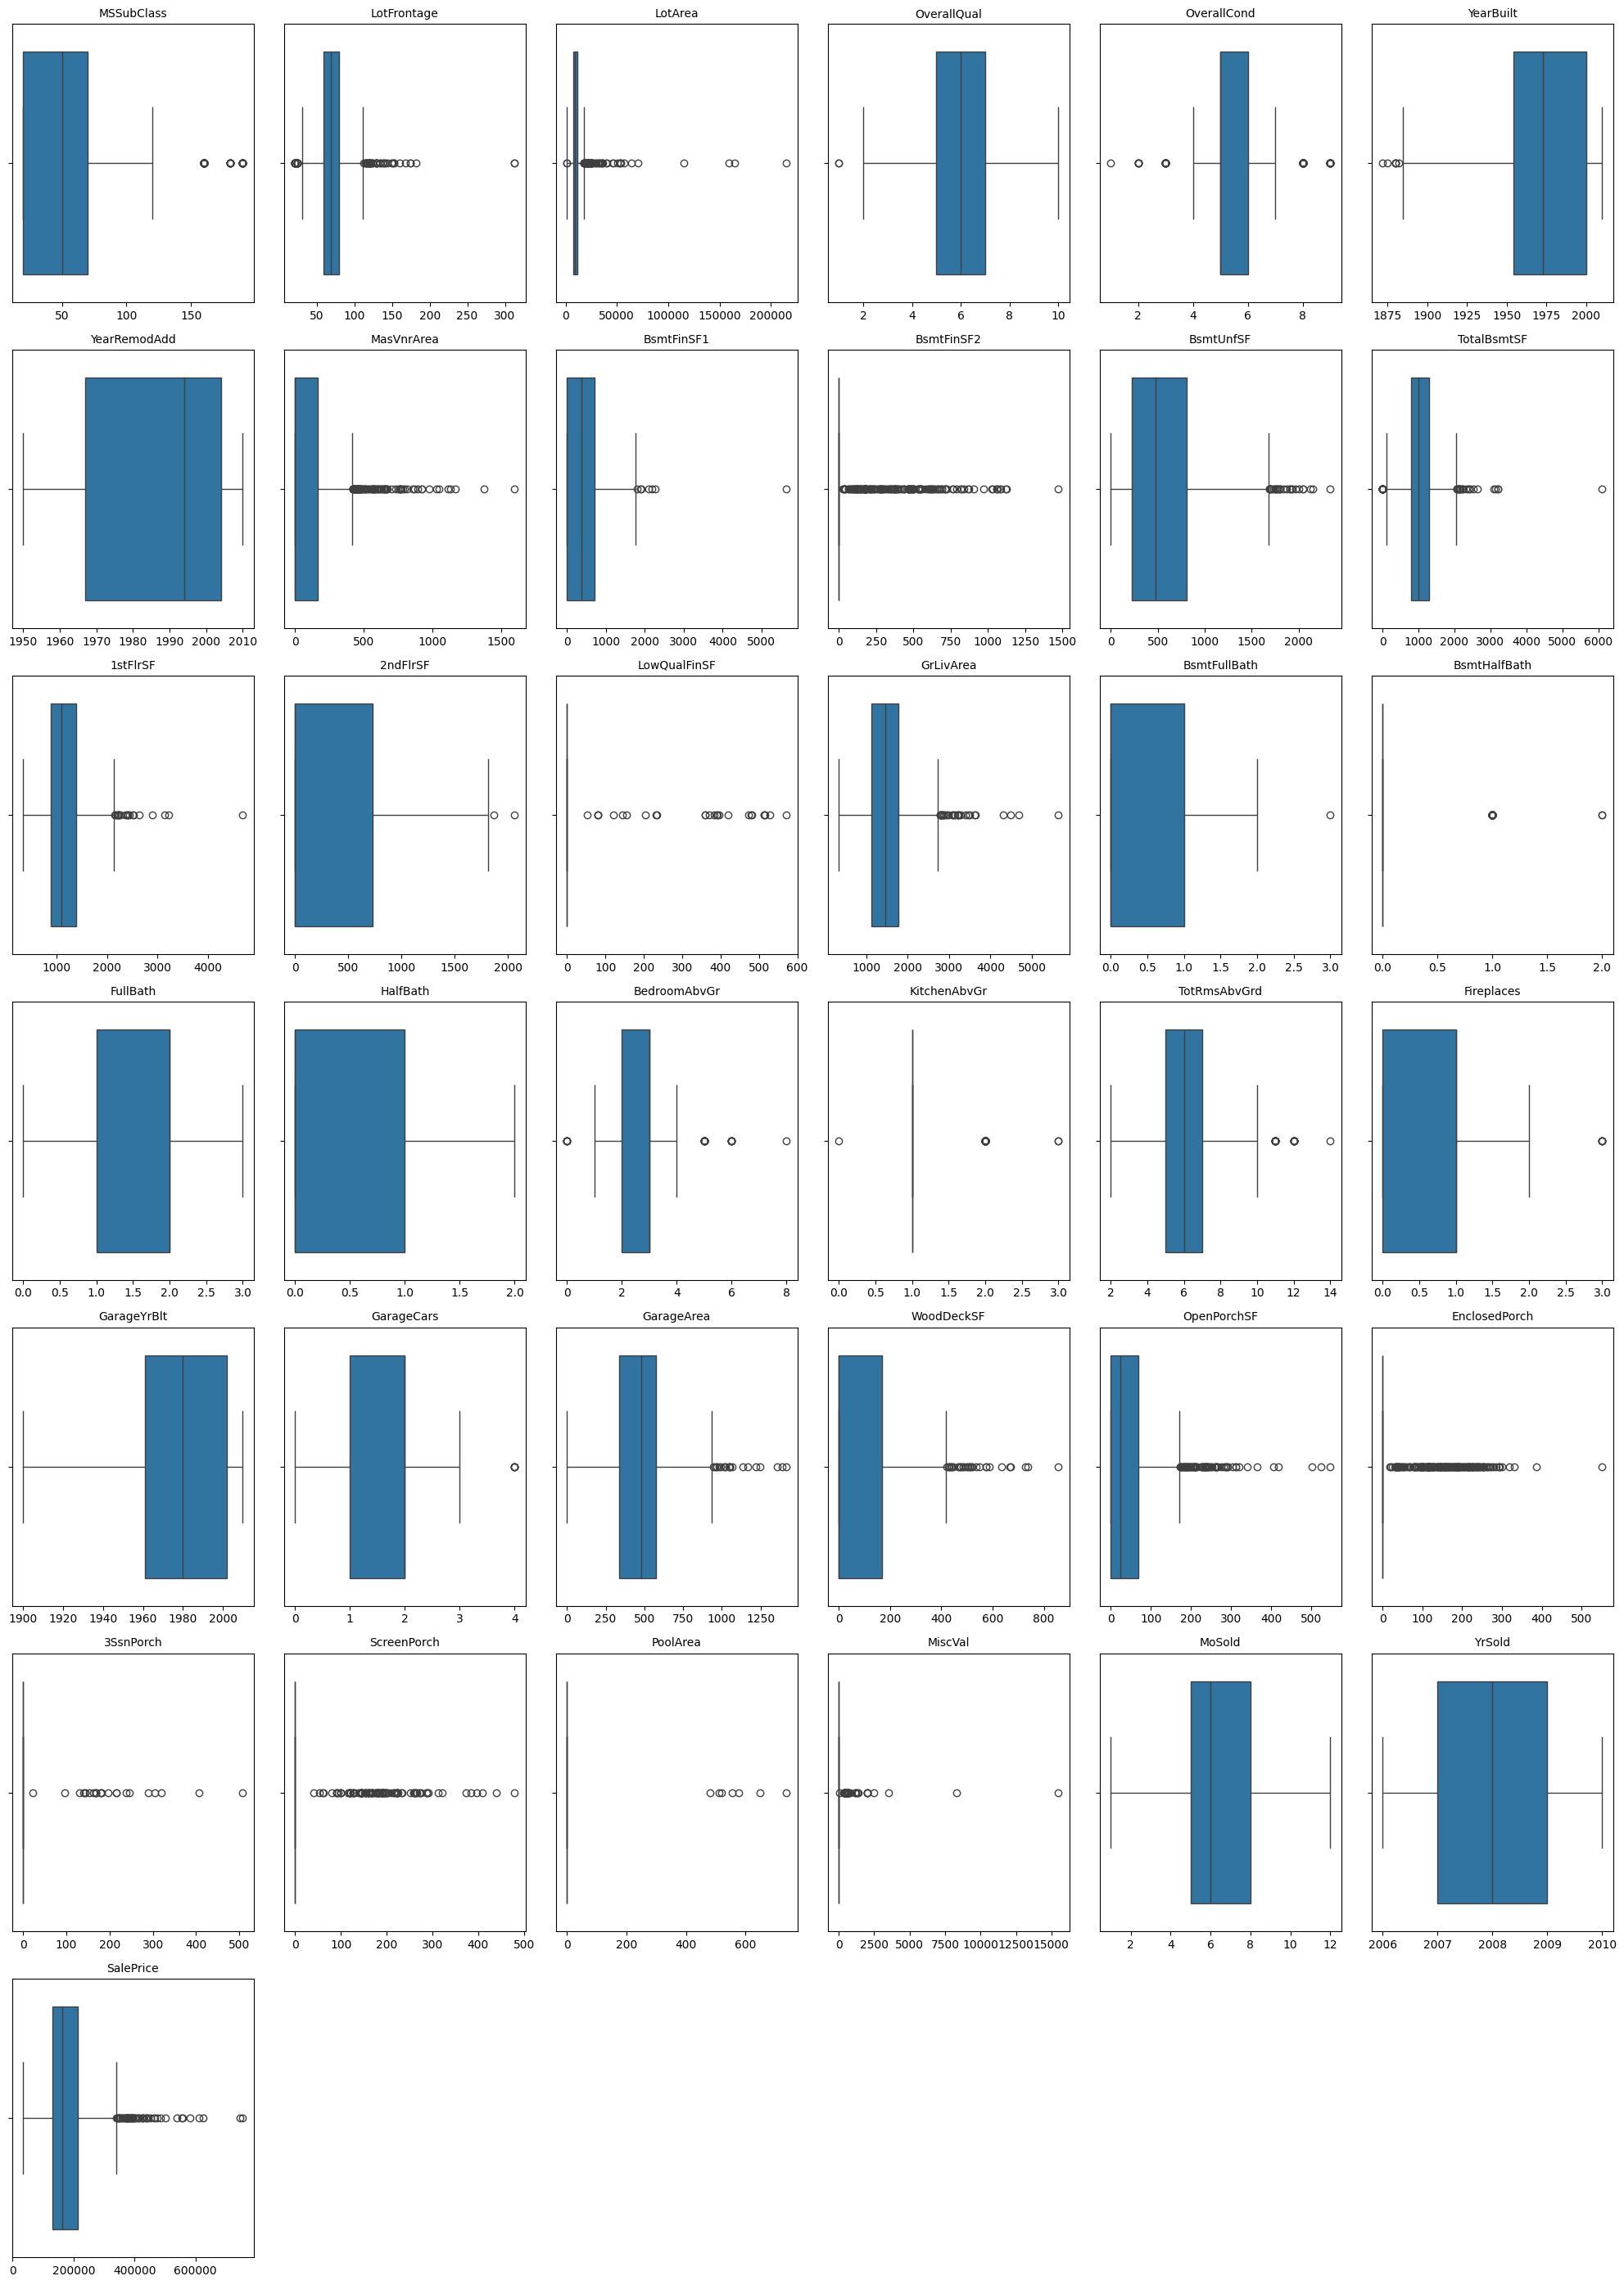

               Qtd_Outliers  Limite_Inf  Limite_Sup
EnclosedPorch         208.0        0.00        0.00
BsmtFinSF2            167.0        0.00        0.00
OverallCond           125.0        3.50        7.50
ScreenPorch           116.0        0.00        0.00
MSSubClass            103.0      -55.00      145.00
MasVnrArea             96.0     -249.00      415.00
LotFrontage            88.0       27.50      111.50
BsmtHalfBath           82.0        0.00        0.00
OpenPorchSF            77.0     -102.00      170.00
LotArea                69.0     1481.50    17673.50
KitchenAbvGr           68.0        1.00        1.00
SalePrice              61.0     3937.50   340037.50
TotalBsmtSF            61.0       42.00     2052.00
MiscVal                52.0        0.00        0.00
BedroomAbvGr           35.0        0.50        4.50
WoodDeckSF             32.0     -252.00      420.00
GrLivArea              31.0      158.62     2747.62
TotRmsAbvGrd           30.0        2.00       10.00
BsmtUnfSF   

In [9]:
# Selecionar apenas variáveis numéricas
df_numerico = df_train.select_dtypes(exclude=['object']).drop(columns=['Id'])

# Boxplots em grade
num_colunas = df_numerico.shape[1]
linhas = (num_colunas // 6) + 1
fig, axes = plt.subplots(nrows=linhas, ncols=6, figsize=(20, linhas*4))
axes = axes.flatten()
for i, col in enumerate(df_numerico.columns):
    sns.boxplot(ax=axes[i], data=df_numerico, x=col)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Contagem via IQR
resultados = {}
for col in df_numerico.columns:
    Q1 = df_numerico[col].quantile(0.25)
    Q3 = df_numerico[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5*IQR
    superior = Q3 + 1.5*IQR
    qtd = df_numerico[(df_numerico[col] < inferior) | (df_numerico[col] > superior)].shape[0]
    resultados[col] = {'Qtd_Outliers': qtd, 'Limite_Inf': round(inferior,2), 'Limite_Sup': round(superior,2)}
tabela_outliers = pd.DataFrame(resultados).T.sort_values('Qtd_Outliers', ascending=False)
print(tabela_outliers)

### **Análise dos Outliers**

A regra do IQR e os boxplots permitiram identificar valores extremos em diversas variáveis numéricas. Esses registros não foram removidos automaticamente, pois um valor extremo não representa necessariamente um erro de cadastro. No contexto imobiliário, imóveis com áreas ou preços muito superiores à média podem representar observações legítimas.

Por esse motivo, os outliers foram identificados e considerados durante a análise, mas sua remoção não foi realizada de forma indiscriminada.

# **Questão 3 – Tratamento de Valores Nulos**

###**Objetivo:**
Eliminar todos os valores nulos nos conjuntos de **treino** e **teste**, utilizando estratégias consistentes para variáveis categóricas e numéricas.

### **Estratégia**

Os conjuntos de treino e teste foram temporariamente concatenados para permitir a aplicação das mesmas regras de tratamento.

Para evitar o uso indevido de informações do conjunto de teste, os valores utilizados para preenchimento por **moda** e **média** foram calculados exclusivamente a partir do conjunto de treino.

O tratamento foi realizado da seguinte forma:

- Variáveis categóricas em que valores ausentes representam a inexistência de uma característica do imóvel foram preenchidas com `missing`.
- As demais variáveis categóricas foram preenchidas com a moda calculada no conjunto de treino.
- As variáveis numéricas foram preenchidas com a média calculada no conjunto de treino.
- A variável-alvo `SalePrice` foi excluída do processo de imputação, pois ela não existe no conjunto de teste original e representa justamente o valor que será previsto pelo modelo.

Após o tratamento, foi verificado que não restaram valores nulos nas features utilizadas pelo modelo. Em seguida, os conjuntos de treino e teste foram novamente separados, preservando `SalePrice` apenas no conjunto de treino.

In [10]:
# ==========================================
# TRATAMENTO DE VALORES NULOS
# ==========================================

print("="*60)
print("INICIANDO TRATAMENTO DE VALORES NULOS")
print("="*60)

# ==========================================
# PASSO 1: IDENTIFICAR TREINO E TESTE
# ==========================================

# Criar uma cópia para evitar alterações indesejadas
df_train = df_train.copy()
df_test = df_test.copy()

# Adicionar coluna indicadora
df_train['ind'] = 'treino'
df_test['ind'] = 'teste'

# Concatenar os dois conjuntos
# O objetivo é aplicar as mesmas regras de tratamento
df_concatenado = pd.concat(
    [df_train, df_test],
    ignore_index=True
)

print(
    f"✅ DataFrame concatenado: "
    f"{df_concatenado.shape[0]} linhas e "
    f"{df_concatenado.shape[1]} colunas."
)

print(
    f"   Treino: {len(df_train)} | "
    f"Teste: {len(df_test)}"
)


# ==========================================
# PASSO 2: DIAGNÓSTICO INICIAL DOS NULOS
# ==========================================

# SalePrice possui NaN no teste porque é a variável
# que deverá ser prevista. Esses NaN são esperados
# e não devem ser tratados.

colunas_features = [
    col for col in df_concatenado.columns
    if col not in ['SalePrice', 'ind']
]

nulos_iniciais = (
    df_concatenado[colunas_features]
    .isnull()
    .sum()
)

total_nulos_inicial = nulos_iniciais.sum()

print("\n" + "="*60)
print("DIAGNÓSTICO INICIAL")
print("="*60)

print(
    f"📊 Total de valores nulos nas FEATURES "
    f"antes do tratamento: {total_nulos_inicial}"
)

if total_nulos_inicial > 0:

    print("\nColunas com maior quantidade de nulos:")

    print(
        nulos_iniciais[
            nulos_iniciais > 0
        ]
        .sort_values(ascending=False)
        .head(10)
    )


# ==========================================
# PASSO 3: COLUNAS QUE REPRESENTAM AUSÊNCIA
# ==========================================

# Nessas colunas, NaN geralmente significa que
# o imóvel NÃO possui aquela característica.

colunas_missing = [
    'ExterQual',
    'BsmtQual',
    'KitchenQual',
    'GarageQual',
    'ExterCond',
    'BsmtCond',
    'GarageCond',
    'FireplaceQu',
    'HeatingQC',
    'PoolQC',
    'Alley',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'GarageType',
    'GarageFinish',
    'Fence',
    'MiscFeature'
]

print("\n" + "="*60)
print(
    "ETAPA 1: Preenchendo ausência de "
    "característica com 'missing'"
)
print("="*60)

for col in colunas_missing:

    if col in df_concatenado.columns:

        qtd_nulos = (
            df_concatenado[col]
            .isnull()
            .sum()
        )

        if qtd_nulos > 0:

            df_concatenado[col] = (
                df_concatenado[col]
                .fillna('missing')
            )

            print(
                f"✅ {col}: "
                f"{qtd_nulos} nulos preenchidos "
                f"com 'missing'"
            )


# ==========================================
# PASSO 4: USAR SOMENTE O TREINO PARA
# CALCULAR MODAS E MÉDIAS
# ==========================================

df_treino_only = (
    df_concatenado[
        df_concatenado['ind'] == 'treino'
    ]
    .copy()
)


# ==========================================
# PASSO 5: DEMAIS COLUNAS CATEGÓRICAS
# ==========================================

print("\n" + "="*60)
print(
    "ETAPA 2: Preenchendo demais colunas "
    "categóricas com a MODA do treino"
)
print("="*60)

colunas_categoricas = (
    df_concatenado
    .select_dtypes(include=['object'])
    .columns
    .tolist()
)

# Remover coluna indicadora e colunas
# já tratadas anteriormente
colunas_categoricas = [
    col for col in colunas_categoricas
    if col != 'ind'
    and col not in colunas_missing
]

for col in colunas_categoricas:

    qtd_nulos = (
        df_concatenado[col]
        .isnull()
        .sum()
    )

    if qtd_nulos > 0:

        moda_treino = (
            df_treino_only[col]
            .mode()
        )

        # Verificação de segurança
        if len(moda_treino) > 0:

            moda = moda_treino.iloc[0]

            df_concatenado[col] = (
                df_concatenado[col]
                .fillna(moda)
            )

            print(
                f"✅ {col}: "
                f"{qtd_nulos} nulos preenchidos "
                f"com moda = '{moda}'"
            )


# ==========================================
# PASSO 6: COLUNAS NUMÉRICAS
# ==========================================

print("\n" + "="*60)
print(
    "ETAPA 3: Preenchendo colunas numéricas "
    "com a MÉDIA do treino"
)
print("="*60)

colunas_numericas = (
    df_concatenado
    .select_dtypes(include=['number'])
    .columns
    .tolist()
)

# IMPORTANTE:
# SalePrice é a variável-alvo.
# Ela NÃO deve ser preenchida no conjunto de teste.

colunas_numericas = [
    col for col in colunas_numericas
    if col != 'SalePrice'
]

for col in colunas_numericas:

    qtd_nulos = (
        df_concatenado[col]
        .isnull()
        .sum()
    )

    if qtd_nulos > 0:

        media = (
            df_treino_only[col]
            .mean()
        )

        df_concatenado[col] = (
            df_concatenado[col]
            .fillna(media)
        )

        print(
            f"✅ {col}: "
            f"{qtd_nulos} nulos preenchidos "
            f"com média = {media:.2f}"
        )


# ==========================================
# PASSO 7: VERIFICAÇÃO FINAL
# ==========================================

print("\n" + "="*60)
print("VERIFICAÇÃO FINAL")
print("="*60)

# Verificar somente as FEATURES.
# SalePrice do teste deve continuar nulo.

colunas_verificacao = [
    col for col in df_concatenado.columns
    if col not in ['SalePrice', 'ind']
]

nulos_finais = (
    df_concatenado[colunas_verificacao]
    .isnull()
    .sum()
)

total_nulos_final = nulos_finais.sum()

print(
    f"📊 Total de valores nulos restantes "
    f"nas FEATURES: {total_nulos_final}"
)

if total_nulos_final == 0:

    print(
        "✅ Nenhum valor nulo restante "
        "nas features."
    )

else:

    print(
        "⚠️ Ainda existem valores nulos "
        "nas seguintes features:"
    )

    print(
        nulos_finais[
            nulos_finais > 0
        ]
        .sort_values(ascending=False)
    )


# ==========================================
# PASSO 8: SEPARAR TREINO E TESTE NOVAMENTE
# ==========================================

print("\n" + "="*60)
print("SEPARANDO TREINO E TESTE")
print("="*60)

df_train_tratado = (
    df_concatenado[
        df_concatenado['ind'] == 'treino'
    ]
    .copy()
    .drop(columns=['ind'])
)

df_test_tratado = (
    df_concatenado[
        df_concatenado['ind'] == 'teste'
    ]
    .copy()
    .drop(columns=['ind'])
)

# O test.csv original não possui SalePrice.
# Remover a coluna criada automaticamente
# durante a concatenação.

if 'SalePrice' in df_test_tratado.columns:

    df_test_tratado = (
        df_test_tratado
        .drop(columns=['SalePrice'])
    )

print(
    f"✅ Treino tratado: "
    f"{df_train_tratado.shape}"
)

print(
    f"✅ Teste tratado: "
    f"{df_test_tratado.shape}"
)

print(
    f"✅ SalePrice presente no treino: "
    f"{'SalePrice' in df_train_tratado.columns}"
)

print(
    f"✅ SalePrice presente no teste: "
    f"{'SalePrice' in df_test_tratado.columns}"
)

print("\n" + "="*60)
print("FIM DO TRATAMENTO DE VALORES NULOS")
print("="*60)

INICIANDO TRATAMENTO DE VALORES NULOS
✅ DataFrame concatenado: 2919 linhas e 82 colunas.
   Treino: 1460 | Teste: 1459

DIAGNÓSTICO INICIAL
📊 Total de valores nulos nas FEATURES antes do tratamento: 15707

Colunas com maior quantidade de nulos:
PoolQC         2909
MiscFeature    2814
Alley          2721
Fence          2348
MasVnrType     1766
FireplaceQu    1420
LotFrontage     486
GarageQual      159
GarageYrBlt     159
GarageCond      159
dtype: int64

ETAPA 1: Preenchendo ausência de característica com 'missing'
✅ BsmtQual: 81 nulos preenchidos com 'missing'
✅ KitchenQual: 1 nulos preenchidos com 'missing'
✅ GarageQual: 159 nulos preenchidos com 'missing'
✅ BsmtCond: 82 nulos preenchidos com 'missing'
✅ GarageCond: 159 nulos preenchidos com 'missing'
✅ FireplaceQu: 1420 nulos preenchidos com 'missing'
✅ PoolQC: 2909 nulos preenchidos com 'missing'
✅ Alley: 2721 nulos preenchidos com 'missing'
✅ BsmtExposure: 82 nulos preenchidos com 'missing'
✅ BsmtFinType1: 79 nulos preenchidos com

# **Questão 4 – Feature Engineering**

##**Feature Engineering – Criação de Novas Variáveis**

Com o objetivo de enriquecer o conjunto de dados e fornecer informações mais relevantes ao modelo, criamos 12 novas variáveis a partir das colunas originais. As principais transformações foram:

**Idade da casa e idade da reforma –** calculadas a partir dos anos de construção, reforma e venda. Essas variáveis capturam o desgaste e a modernização do imóvel.

**Área total considerada –** inclui porão, primeiro e segundo andar.

**Indicadores binários –** indicam se o imóvel possui garagem, piscina, lareira ou porão, simplificando informações categóricas.

**Qualidade geral –** produto de OverallQual e OverallCond, combinando qualidade dos materiais e condição geral.

**Proporção de área construída –** relação entre área habitável e área do terreno, útil para identificar terrenos subaproveitados.

**Total de banheiros –** soma de todos os banheiros (incluindo porão), substituindo quatro colunas separadas.

**Porão acabado total –** soma das áreas de porão acabado, resumindo duas colunas.

**Com isso**, removemos 6 colunas que foram resumidas em novas variáveis, reduzindo a redundância entre algumas informações relacionadas e deixando o conjunto de dados mais condensado e interpretável.

In [11]:
# ==========================================
# FEATURE ENGINEERING - COM LOGS DETALHADOS
# ==========================================

print("="*70)
print("INICIANDO FEATURE ENGINEERING")
print("="*70)


# ==========================================
# FUNÇÃO DE FEATURE ENGINEERING
# ==========================================

def aplicar_feature_engineering_com_logs(df, nome_df="DataFrame"):
    """
    Aplica Feature Engineering ao DataFrame,
    criando novas variáveis a partir das informações existentes.

    A mesma função é aplicada aos conjuntos de treino e teste
    para garantir consistência nas transformações.

    Retorna o DataFrame modificado.
    """

    print(f"\n📌 Processando {nome_df}...")

    # Criar uma cópia para não alterar o DataFrame original
    df = df.copy()

    # Armazenar as colunas originais para comparação
    colunas_originais = set(df.columns)

    print(f" Colunas originais: {len(colunas_originais)}")


    # ==========================================
    # 1. CRIAÇÃO DE NOVAS VARIÁVEIS
    # ==========================================

    # Idade da casa no momento da venda
    df['Idade'] = (
        df['YrSold'] -
        df['YearBuilt']
    )

    # Tempo desde a última reforma até o momento da venda
    df['IdadeReforma'] = (
        df['YrSold'] -
        df['YearRemodAdd']
    )

    # Área total considerada:
    # porão + primeiro andar + segundo andar
    df['AreaTotal'] = (
        df['TotalBsmtSF'] +
        df['1stFlrSF'] +
        df['2ndFlrSF']
    )

    # Área total do porão:
    # partes acabadas + parte não acabada
    df['AreaPoraoTotal'] = (
        df['BsmtFinSF1'] +
        df['BsmtFinSF2'] +
        df['BsmtUnfSF']
    )

    # Indicador de existência de garagem
    df['TemGaragem'] = (
        df['GarageCars'] > 0
    ).astype(int)

    # Indicador de existência de piscina
    df['TemPiscina'] = (
        df['PoolArea'] > 0
    ).astype(int)

    # Indicador de existência de lareira
    df['TemLareira'] = (
        df['Fireplaces'] > 0
    ).astype(int)

    # Indicador de existência de porão
    df['TemPorão'] = (
        df['TotalBsmtSF'] > 0
    ).astype(int)

    # Interação entre qualidade geral
    # e condição geral do imóvel
    df['QualidadeGeral'] = (
        df['OverallQual'] *
        df['OverallCond']
    )

    # Proporção da área habitável em relação
    # à área total do terreno
    # replace(0, 1) evita divisão por zero
    df['ProporcaoArea'] = (
        df['GrLivArea'] /
        df['LotArea'].replace(0, 1)
    )

    # Total equivalente de banheiros
    #
    # Banheiro completo = 1
    # Meio banheiro = 0.5
    #
    # Também são considerados os banheiros
    # localizados no porão.
    df['TotalBanheiros'] = (
        df['FullBath'] +
        0.5 * df['HalfBath'] +
        df['BsmtFullBath'] +
        0.5 * df['BsmtHalfBath']
    )

    # Área acabada do porão
    # soma dos dois tipos de área acabada
    df['TotalBsmtFinSF'] = (
        df['BsmtFinSF1'] +
        df['BsmtFinSF2']
    )


    # ==========================================
    # 2. REMOVER COLUNAS QUE FORAM RESUMIDAS
    # ==========================================

    # Essas informações já foram incorporadas
    # às novas features criadas acima.
    colunas_remover = [
        'BsmtFinSF1',
        'BsmtFinSF2',
        'FullBath',
        'HalfBath',
        'BsmtFullBath',
        'BsmtHalfBath'
    ]

    df.drop(
        columns=colunas_remover,
        inplace=True
    )


    # ==========================================
    # 3. IDENTIFICAR NOVAS COLUNAS
    # ==========================================

    novas_colunas = (
        set(df.columns) -
        colunas_originais
    )

    print(
        f" Novas colunas criadas: "
        f"{len(novas_colunas)}"
    )

    print(" Lista das novas colunas:")

    for col in sorted(novas_colunas):
        print(f"      - {col}")

    print(
        f" Colunas removidas: "
        f"{len(colunas_remover)}"
    )

    print(
        f" Colunas removidas: "
        f"{colunas_remover}"
    )

    print(
        f" Total de colunas após FE: "
        f"{len(df.columns)}"
    )


    # ==========================================
    # 4. ESTATÍSTICAS DAS NOVAS VARIÁVEIS
    # ==========================================

    print(
        "\n📊 Estatísticas descritivas "
        "das novas variáveis:"
    )

    # Ordenar para manter uma saída consistente
    novas_colunas_ordenadas = sorted(
        novas_colunas
    )

    print(
        df[
            novas_colunas_ordenadas
        ]
        .describe()
        .round(2)
    )


    # ==========================================
    # RETORNAR DATAFRAME MODIFICADO
    # ==========================================

    return df


# ==========================================
# APLICAR FEATURE ENGINEERING
# ==========================================

# Aplicar exatamente as mesmas transformações
# ao treino e ao teste

df_train_fe = aplicar_feature_engineering_com_logs(
    df_train_tratado,
    "Treino"
)

df_test_fe = aplicar_feature_engineering_com_logs(
    df_test_tratado,
    "Teste"
)


# ==========================================
# VERIFICAÇÃO FINAL
# ==========================================

print("\n" + "="*70)
print("VERIFICAÇÃO FINAL")
print("="*70)

print(
    f"✅ Treino após Feature Engineering: "
    f"{df_train_fe.shape}"
)

print(
    f"✅ Teste após Feature Engineering:  "
    f"{df_test_fe.shape}"
)


# ==========================================
# COMPARAR AS FEATURES DE TREINO E TESTE
# ==========================================

# SalePrice existe somente no conjunto de treino,
# pois é justamente a variável que queremos prever.
#
# Portanto, para verificar se treino e teste possuem
# as mesmas features, SalePrice deve ser excluído
# da comparação.

colunas_treino_sem_alvo = (
    df_train_fe
    .drop(
        columns=['SalePrice'],
        errors='ignore'
    )
    .columns
    .tolist()
)

colunas_teste = (
    df_test_fe
    .columns
    .tolist()
)

features_identicas = (
    colunas_treino_sem_alvo ==
    colunas_teste
)

print(
    f"✅ Features de treino e teste "
    f"são idênticas? {features_identicas}"
)


# ==========================================
# VERIFICAÇÃO DA VARIÁVEL ALVO
# ==========================================

print(
    f"✅ SalePrice presente no treino? "
    f"{'SalePrice' in df_train_fe.columns}"
)

print(
    f"✅ SalePrice presente no teste? "
    f"{'SalePrice' in df_test_fe.columns}"
)


# ==========================================
# RESULTADO FINAL
# ==========================================

if features_identicas:

    print(
        "\n✅ Feature Engineering concluído "
        "com sucesso."
    )

    print(
        "✅ Treino e teste possuem "
        "as mesmas variáveis preditoras."
    )

else:

    print(
        "\n⚠️ Atenção: existem diferenças "
        "entre as features de treino e teste."
    )

    # Mostrar diferenças para facilitar diagnóstico
    features_treino = set(
        colunas_treino_sem_alvo
    )

    features_teste = set(
        colunas_teste
    )

    somente_treino = (
        features_treino -
        features_teste
    )

    somente_teste = (
        features_teste -
        features_treino
    )

    print(
        f"Features somente no treino: "
        f"{sorted(somente_treino)}"
    )

    print(
        f"Features somente no teste: "
        f"{sorted(somente_teste)}"
    )


print("="*70)

INICIANDO FEATURE ENGINEERING

📌 Processando Treino...
 Colunas originais: 81
 Novas colunas criadas: 12
 Lista das novas colunas:
      - AreaPoraoTotal
      - AreaTotal
      - Idade
      - IdadeReforma
      - ProporcaoArea
      - QualidadeGeral
      - TemGaragem
      - TemLareira
      - TemPiscina
      - TemPorão
      - TotalBanheiros
      - TotalBsmtFinSF
 Colunas removidas: 6
 Colunas removidas: ['BsmtFinSF1', 'BsmtFinSF2', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
 Total de colunas após FE: 87

📊 Estatísticas descritivas das novas variáveis:
       AreaPoraoTotal  AreaTotal    Idade  IdadeReforma  ProporcaoArea  \
count         1460.00    1460.00  1460.00       1460.00        1460.00   
mean          1057.43    2567.05    36.55         22.95           0.18   
std            438.71     821.71    30.25         20.64           0.11   
min              0.00     334.00     0.00         -1.00           0.01   
25%            795.75    2009.50     8.00          4

Embora os conjuntos de treino e teste tenham sido concatenados para facilitar a aplicação das mesmas regras de tratamento, os valores utilizados para imputação por média e moda foram calculados exclusivamente a partir do conjunto de treino. Dessa forma, evitamos utilizar informações estatísticas do conjunto de teste na definição dos valores de preenchimento.

# **Questão 5 – Criação de Variáveis Dummies**

##**Objetivo:**
Transformar todas as variáveis categóricas (tipo object) em variáveis dummy (binárias 0/1) para que possam ser utilizadas por modelos de regressão, que exigem entradas numéricas.

##**Metodologia:**
* **Identificação das colunas categóricas** – selecionar todas as colunas de tipo object.
* **Aplicação do one-hot encoding** – usar pd.get_dummies() para criar colunas binárias para cada categoria.
* **Alinhamento entre treino e teste** – garantir que ambos os conjuntos tenham exatamente as mesmas colunas, mesmo que algumas categorias não apareçam em um dos conjuntos. Isso é feito com o método .align(join='left', fill_value=0).
* **Separação das features (X) e do alvo (y)** – no treino, removemos Id e SalePrice; no teste, removemos apenas Id.

In [12]:
# ==========================================
# CRIAÇÃO DE VARIÁVEIS DUMMIES (ONE-HOT ENCODING)
# ==========================================

print("="*70)
print("INICIANDO CRIAÇÃO DE VARIÁVEIS DUMMIES")
print("="*70)

# PASSO 1: Identificar colunas categóricas (tipo 'object')
colunas_cat = df_train_fe.select_dtypes(include=['object']).columns.tolist()
print(f"\n🔹 Colunas categóricas identificadas: {len(colunas_cat)}")
print(" Lista das colunas categóricas:")
for i, col in enumerate(colunas_cat, 1):
    print(f"      {i:2d}. {col}")

# PASSO 2: Aplicar get_dummies separadamente
print("\n" + "="*70)
print("APLICANDO ONE-HOT ENCODING")
print("="*70)

df_train_dummies = pd.get_dummies(df_train_fe, columns=colunas_cat, drop_first=False)
df_test_dummies  = pd.get_dummies(df_test_fe, columns=colunas_cat, drop_first=False)

print(f"\n✅ Treino após dummies: {df_train_dummies.shape} (linhas, colunas)")
print(f"✅ Teste após dummies:  {df_test_dummies.shape} (linhas, colunas)")

# PASSO 3: Verificar diferenças entre as colunas
colunas_treino = set(df_train_dummies.columns)
colunas_teste  = set(df_test_dummies.columns)

faltam_no_teste = colunas_treino - colunas_teste
faltam_no_treino = colunas_teste - colunas_treino

print(f"\n🔹 Colunas que existem no treino mas NÃO no teste: {len(faltam_no_teste)}")
if len(faltam_no_teste) > 0:
    print(" Exemplos (primeiras 5):")
    for col in list(faltam_no_teste)[:5]:
        print(f"      - {col}")

print(f"🔹 Colunas que existem no teste mas NÃO no treino: {len(faltam_no_treino)}")
if len(faltam_no_treino) > 0:
    print(" Exemplos (primeiras 5):")
    for col in list(faltam_no_treino)[:5]:
        print(f"      - {col}")

# PASSO 4: Alinhar as colunas (join='left' mantém as do treino)
print("\n" + "="*70)
print("ALINHANDO COLUNAS ENTRE TREINO E TESTE")
print("="*70)

df_train_dummies, df_test_dummies = df_train_dummies.align(
    df_test_dummies, join='left', axis=1, fill_value=0
)

print(f"\n✅ Após alinhamento:")
print(f" Treino: {df_train_dummies.shape}")
print(f" Teste:  {df_test_dummies.shape}")

# PASSO 5: Verificar se as colunas são idênticas
if df_train_dummies.columns.tolist() == df_test_dummies.columns.tolist():
    print("🎉 Colunas alinhadas! (mesma ordem e nomes)")
else:
    print("⚠️ Ainda há diferenças. Verifique manualmente.")

# PASSO 6: Separar X (features) e y (alvo)
print("\n" + "="*70)
print("SEPARANDO FEATURES (X) E ALVO (y)")
print("="*70)

X_train = df_train_dummies.drop(columns=['Id', 'SalePrice'])
y_train = df_train_dummies['SalePrice']

X_test = df_test_dummies.drop(columns=['Id'])
# Se por acaso 'SalePrice' estiver no teste (não deveria), removemos
if 'SalePrice' in X_test.columns:
    X_test = X_test.drop(columns=['SalePrice'])

print(f"\n✅ X_train: {X_train.shape} (amostras, features)")
print(f"✅ y_train: {y_train.shape} (amostras)")
print(f"✅ X_test:  {X_test.shape} (amostras, features)")

# PASSO 7: Verificação final de consistência
print("\n" + "="*70)
print("VERIFICAÇÃO FINAL DE CONSISTÊNCIA")
print("="*70)

if X_train.columns.tolist() == X_test.columns.tolist():
    print(f"\n🎉 X_train e X_test têm exatamente as mesmas colunas!")
    print(f" Total de colunas: {len(X_train.columns)}")
else:
    print("⚠️ ALERTA: As colunas de X_train e X_test são diferentes!")
    print(f" Colunas só no treino: {set(X_train.columns) - set(X_test.columns)}")
    print(f" Colunas só no teste:  {set(X_test.columns) - set(X_train.columns)}")

print("\n" + "="*70)
print("FIM DA CRIAÇÃO DE DUMMIES")
print("="*70)

INICIANDO CRIAÇÃO DE VARIÁVEIS DUMMIES

🔹 Colunas categóricas identificadas: 43
 Lista das colunas categóricas:
       1. MSZoning
       2. Street
       3. Alley
       4. LotShape
       5. LandContour
       6. Utilities
       7. LotConfig
       8. LandSlope
       9. Neighborhood
      10. Condition1
      11. Condition2
      12. BldgType
      13. HouseStyle
      14. RoofStyle
      15. RoofMatl
      16. Exterior1st
      17. Exterior2nd
      18. MasVnrType
      19. ExterQual
      20. ExterCond
      21. Foundation
      22. BsmtQual
      23. BsmtCond
      24. BsmtExposure
      25. BsmtFinType1
      26. BsmtFinType2
      27. Heating
      28. HeatingQC
      29. CentralAir
      30. Electrical
      31. KitchenQual
      32. Functional
      33. FireplaceQu
      34. GarageType
      35. GarageFinish
      36. GarageQual
      37. GarageCond
      38. PavedDrive
      39. PoolQC
      40. Fence
      41. MiscFeature
      42. SaleType
      43. SaleCondition

APLICAN

## **Criação de Variáveis Dummies (One-Hot Encoding)**

As 43 variáveis categóricas (texto) foram transformadas em variáveis binárias utilizando o método pd.get_dummies(). Esse processo gerou, inicialmente, 309 colunas no treino e 292 no teste. A diferença ocorre porque algumas categorias aparecem apenas em um dos conjuntos (ex: um bairro presente apenas no treino).

Para garantir a compatibilidade entre `treino e teste` – condição essencial para a aplicação do modelo – utilizamos o alinhamento com `join='left'`, mantendo todas as colunas do treino e adicionando no teste as colunas faltantes com valor zero (0). Isso resultou em 309 colunas em ambos os conjuntos.

**Após remover as colunas Id e SalePrice (alvo), obtivemos:**
* X_train: 1460 amostras × 307 features
* y_train: 1460 amostras
* X_test: 1459 amostras × 307 features

**Verificação de consistência:** As 307 features são exatamente as mesmas nos dois conjuntos, garantindo que o modelo possa ser aplicado ao teste sem erros de dimensionalidade. Esse alinhamento é fundamental para a predição final.

**Resumo Final:**

* Colunas categóricas: 43
* Colunas após dummies (treino): 309
* Colunas após dummies (teste): 309 (após alinhamento)
* Features finais (X_train/X_test): 307 (excluídos Id e SalePrice)
* Consistência: 100% entre treino e teste
* Agora os dados estão prontos para a modelagem preditiva. 🚀

#**Questão 6 – Separação dos Dados de Treino e Validação**

##**Objetivo:**
Separar o conjunto de treino em duas partes: uma para treinar o modelo e outra para validar seu desempenho antes de fazer a previsão final no arquivo de teste. Essa etapa é fundamental para avaliar a capacidade de generalização do modelo e evitar overfitting.

##**Metodologia:**
* Manter o conjunto de teste original (X_test) – este conjunto será usado apenas uma vez, no final, para gerar as previsões finais.
* Dividir o treino (X_train, y_train) – usamos train_test_split do scikit-learn para separar aleatoriamente 20% dos dados para validação e 80% para treino efetivo.
* Garantir reprodutibilidade – definimos random_state=42 para que a divisão seja sempre a mesma.
* Preservar a distribuição – o parâmetro stratify não é usado porque a variável alvo é contínua (regressão).



In [13]:
# ==========================================
# SEPARAÇÃO TREINO-VALIDAÇÃO (HOLD-OUT)
# ==========================================

print("="*70)
print("SEPARANDO CONJUNTO DE VALIDAÇÃO (HOLD-OUT)")
print("="*70)

# Exibir os shapes atuais
print(f"\n📊 Dados disponíveis antes da separação:")
print(f" X_train: {X_train.shape}")
print(f" y_train: {y_train.shape}")
print(f" X_test:  {X_test.shape}")

# PASSO 1: Dividir o treino em treino (80%) e validação (20%)
from sklearn.model_selection import train_test_split

X_train_val, X_val, y_train_val, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,          # 20% para validação
    random_state=42         # Semente para reprodutibilidade
)

print("\n" + "="*70)
print("RESULTADO DA DIVISÃO")
print("="*70)

print(f"\n✅ Conjunto de TREINO (para treinar o modelo):")
print(f" X_train_val: {X_train_val.shape[0]} amostras, {X_train_val.shape[1]} features")
print(f" y_train_val: {y_train_val.shape[0]} amostras")

print(f"\n✅ Conjunto de VALIDAÇÃO (para avaliar o modelo):")
print(f" X_val:       {X_val.shape[0]} amostras, {X_val.shape[1]} features")
print(f" y_val:       {y_val.shape[0]} amostras")

print(f"\n✅ Conjunto de TESTE FINAL (mantido intacto):")
print(f" X_test:      {X_test.shape[0]} amostras, {X_test.shape[1]} features")

# PASSO 2: Verificar se as colunas são consistentes
print("\n" + "="*70)
print("VERIFICAÇÃO DE CONSISTÊNCIA DAS COLUNAS")
print("="*70)

if (X_train_val.columns.tolist() == X_val.columns.tolist() == X_test.columns.tolist()):
    print("🎉 Todos os conjuntos (treino, validação, teste) têm as MESMAS colunas!")
    print(f" Total de colunas em cada: {len(X_train_val.columns)}")
else:
    print("⚠️ Atenção: os conjuntos têm colunas diferentes. Verifique o alinhamento.")

# PASSO 3: Estatísticas resumidas da variável alvo nos conjuntos
print("\n" + "="*70)
print("ESTATÍSTICAS DA VARIÁVEL ALVO (SalePrice) EM CADA CONJUNTO")
print("="*70)

print("\n📈 Treino (80%):")
print(y_train_val.describe().round(2))

print("\n📈 Validação (20%):")
print(y_val.describe().round(2))

print("\n📈 Teste Final:")
print("O conjunto de teste do Kaggle não possui a variável SalePrice.")

SEPARANDO CONJUNTO DE VALIDAÇÃO (HOLD-OUT)

📊 Dados disponíveis antes da separação:
 X_train: (1460, 307)
 y_train: (1460,)
 X_test:  (1459, 307)

RESULTADO DA DIVISÃO

✅ Conjunto de TREINO (para treinar o modelo):
 X_train_val: 1168 amostras, 307 features
 y_train_val: 1168 amostras

✅ Conjunto de VALIDAÇÃO (para avaliar o modelo):
 X_val:       292 amostras, 307 features
 y_val:       292 amostras

✅ Conjunto de TESTE FINAL (mantido intacto):
 X_test:      1459 amostras, 307 features

VERIFICAÇÃO DE CONSISTÊNCIA DAS COLUNAS
🎉 Todos os conjuntos (treino, validação, teste) têm as MESMAS colunas!
 Total de colunas em cada: 307

ESTATÍSTICAS DA VARIÁVEL ALVO (SalePrice) EM CADA CONJUNTO

📈 Treino (80%):
count      1168.00
mean     181441.54
std       77263.58
min       34900.00
25%      130000.00
50%      165000.00
75%      214925.00
max      745000.00
Name: SalePrice, dtype: float64

📈 Validação (20%):
count       292.00
mean     178839.81
std       87730.75
min       35311.00
25%      

## **Separação dos Dados de Treino e Validação**

Para avaliar a performance do modelo de forma confiável, o conjunto de treino original, composto por **1.460 amostras**, foi dividido em dois subconjuntos:

- **Treino (80%)**: 1.168 amostras — utilizado para ajustar os parâmetros do modelo.
- **Validação (20%)**: 292 amostras — utilizado para avaliar o desempenho do modelo e auxiliar no ajuste dos hiperparâmetros, sem participar diretamente do treinamento.

O conjunto de **teste original**, composto por **1.459 amostras**, foi mantido completamente isolado. Esse conjunto não possui a variável `SalePrice`, portanto será utilizado somente ao final do projeto para gerar as previsões finais e o arquivo de submissão para o Kaggle.

### **Verificação de consistência**

Após o pré-processamento, os conjuntos de treino, validação e teste possuem exatamente as mesmas **307 features**, garantindo que o modelo possa receber os três conjuntos de dados com a mesma estrutura.

### **Análise da variável-alvo**

Como o conjunto de teste original não possui a variável `SalePrice`, a análise da variável-alvo foi realizada apenas nos conjuntos de **treino e validação**.

As estatísticas descritivas da variável `SalePrice` nos dois conjuntos apresentam valores semelhantes, com médias próximas de **US\$ 180 mil** e desvios-padrão próximos de **US\$ 79 mil**. Isso indica que a divisão entre treino e validação foi realizada de forma aleatória e representativa dos dados originais.

Essa separação é essencial para evitar **data leakage** e obter uma estimativa mais realista da performance do modelo antes de realizar as previsões no conjunto de teste final.

# **Questão 7 – Desenvolvimento do Modelo de Regressão e Validação**

##**Objetivo:**
Construir, treinar e validar modelos de machine learning para prever o preço de venda dos imóveis (SalePrice). Os modelos são avaliados com métricas de erro e, após a escolha do melhor, geramos as previsões finais para o arquivo de teste do Kaggle.

##**Metodologia:**
**Modelos testados:**

- **Regressão Linear –** modelo base para referência.
- **Random Forest Regressor –** modelo ensemble robusto para capturar relações não lineares.
- **Random Forest com transformação log –** aplicação de log na variável alvo para lidar com a assimetria da distribuição.

**Métricas de avaliação:**

- **RMSE (Root Mean Squared Error) –** erro médio em dólares. Quanto menor, melhor.
- **R² (Coeficiente de Determinação)** – indica quanto da variabilidade da variável-alvo é explicada pelo modelo. Quanto mais próximo de 1, melhor o ajuste. O R² também pode assumir valores negativos quando o modelo apresenta desempenho inferior a uma previsão baseada apenas na média.
- **Validação:** Os modelos são treinados no conjunto de treino (80%) e avaliados no conjunto de validação (20%), garantindo uma estimativa realista de performance.
- **Modelo final:** Treinado com todos os dados de treino (X_train, y_train) para maximizar a capacidade preditiva.
- **Submissão:** Geração do arquivo submission.csv com as previsões para o Kaggle.
- **Interpretabilidade:** Análise da importância das variáveis para entender os principais fatores que influenciam o preço.

## Desenvolvimento e Validação do Modelo de Regressão

Foram testados três modelos para prever o preço dos imóveis:

1. **Regressão Linear** – apresentou RMSE de aproximadamente **US\$ 66,3 mil** e R² de **0,4264**, indicando desempenho inferior aos modelos baseados em árvores e sugerindo que as relações entre as características dos imóveis e o preço não são exclusivamente lineares.

2. **Random Forest** – apresentou o melhor desempenho entre os modelos avaliados, com RMSE de aproximadamente **US\$ 29,3 mil** e R² de **0,8881**. O modelo foi capaz de capturar relações não lineares e interações entre as características dos imóveis.

3. **Random Forest com transformação logarítmica** – apresentou RMSE de aproximadamente **US\$ 29,9 mil** e R² de **0,8835**. Embora a transformação logarítmica tenha apresentado desempenho próximo ao Random Forest original, neste conjunto de validação ela não trouxe melhora nas métricas avaliadas.

### Validação Cruzada

Para avaliar a estabilidade do Random Forest, também foi aplicada validação cruzada com **5 folds**.

O modelo apresentou:

- **R² médio:** 0,8640
- **RMSE médio:** aproximadamente US\$ 29,1 mil

Os resultados da validação cruzada são próximos aos obtidos na divisão treino/validação, indicando que o desempenho do modelo se mantém relativamente consistente em diferentes subconjuntos dos dados.

### Modelo Final

Com base nos resultados obtidos, o **Random Forest sem transformação logarítmica** foi escolhido como modelo final.

Após a validação, o modelo foi treinado novamente utilizando todos os **1.460 registros do conjunto de treino** e aplicado às **1.459 casas do conjunto de teste**.

As previsões foram utilizadas para gerar o arquivo `submission.csv`, no formato necessário para submissão no Kaggle.

### Importância das Variáveis

A análise de importância das features do Random Forest mostrou que as variáveis com maior importância relativa foram:

- **AreaTotal:** aproximadamente 42,7%
- **OverallQual:** aproximadamente 33,0%
- **2ndFlrSF:** aproximadamente 2,6%
- **QualidadeGeral:** aproximadamente 2,3%
- **YearBuilt:** aproximadamente 1,4%
- **TotalBanheiros:** aproximadamente 1,0%
- **Idade:** aproximadamente 1,0%

Esses valores representam a **importância relativa atribuída pelo Random Forest durante a construção das árvores**, não uma relação direta de causalidade com o preço dos imóveis.

De forma geral, o modelo indica que características relacionadas à área do imóvel, qualidade geral, idade e quantidade de banheiros possuem papel relevante na previsão do preço de venda.

In [14]:
# ==========================================
# TREINAMENTO E COMPARAÇÃO DOS MODELOS
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

resultados_modelos = {}

# 1. Regressão Linear
lr = LinearRegression()
lr.fit(X_train_val, y_train_val)

y_pred_lr = lr.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr = r2_score(y_val, y_pred_lr)

resultados_modelos['Regressão Linear'] = {
    'RMSE': rmse_lr,
    'R2': r2_lr
}

# 2. Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_val, y_train_val)

y_pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

resultados_modelos['Random Forest'] = {
    'RMSE': rmse_rf,
    'R2': r2_rf
}

# 3. Random Forest com log
rf_log = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

y_train_val_log = np.log(y_train_val)

rf_log.fit(X_train_val, y_train_val_log)

y_pred_log = np.exp(
    rf_log.predict(X_val)
)

rmse_log = np.sqrt(
    mean_squared_error(y_val, y_pred_log)
)

r2_log = r2_score(
    y_val,
    y_pred_log
)

resultados_modelos['Random Forest + log'] = {
    'RMSE': rmse_log,
    'R2': r2_log
}

# Comparação
df_resultados = pd.DataFrame(resultados_modelos).T
df_resultados = df_resultados.sort_values(
    'RMSE',
    ascending=True
)

print("Comparação dos modelos:")
display(df_resultados.round(4))

melhor_modelo_nome = df_resultados.index[0]

print(
    f"\nMelhor modelo: {melhor_modelo_nome}"
)

Comparação dos modelos:


,RMSE,R2
Random Forest,29300.7960,0.8881
Random Forest + log,29886.6280,0.8835
Regressão Linear,66331.3709,0.4264



Melhor modelo: Random Forest


In [15]:
# ==========================================
# VALIDAÇÃO CRUZADA (CROSS-VALIDATION) - 5 FOLDS
# ==========================================

print("\n" + "="*70)
print("VALIDANDO O MODELO COM CROSS-VALIDATION (5 FOLDS)")
print("="*70)

from sklearn.model_selection import cross_val_score

# Criar um Random Forest específico para a validação cruzada
rf_cv = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# R² em cada fold
scores_r2 = cross_val_score(
    rf_cv,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

# RMSE em cada fold
scores_rmse = np.sqrt(
    -cross_val_score(
        rf_cv,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

print(f"R² em cada fold: {scores_r2}")
print(f"R² médio: {scores_r2.mean():.4f} (+/- {scores_r2.std():.4f})")
print(f"RMSE médio: ${scores_rmse.mean():,.2f} (+/- ${scores_rmse.std():,.2f})")


VALIDANDO O MODELO COM CROSS-VALIDATION (5 FOLDS)
R² em cada fold: [0.88271171 0.83877934 0.88421945 0.89457393 0.81954155]
R² médio: 0.8640 (+/- 0.0293)
RMSE médio: $29,107.41 (+/- $4,324.59)


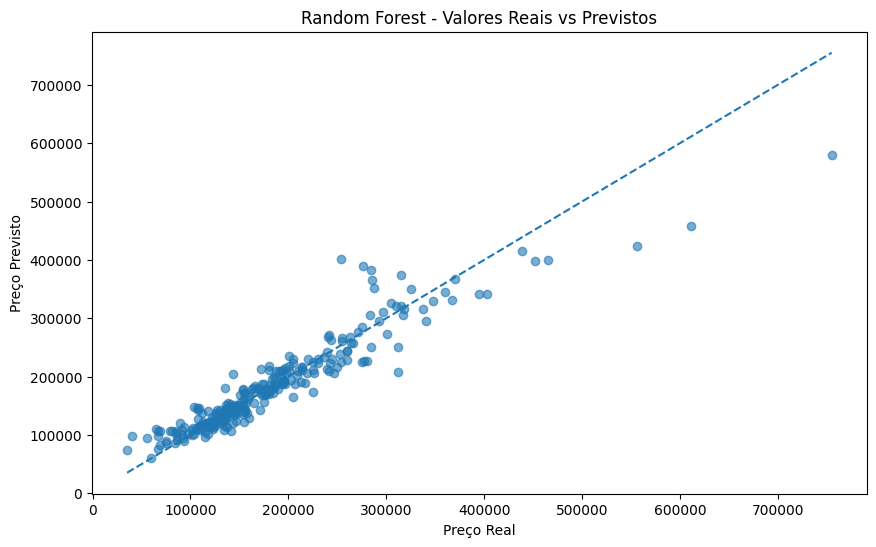

In [16]:
# ==========================================
# GRÁFICO: VALORES REAIS VS PREVISÕES
# ==========================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_val,
    y_pred_rf,
    alpha=0.6
)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle='--'
)

plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Random Forest - Valores Reais vs Previstos')

plt.show()

In [17]:
# O melhor modelo foi o Random Forest sem transformação log
print(f"📌 Treinando {melhor_modelo_nome} com todos os dados...")

rf_final = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

print("✅ Modelo final treinado com sucesso!")

📌 Treinando Random Forest com todos os dados...
✅ Modelo final treinado com sucesso!


In [18]:
# ==========================================
# GERAR PREVISÕES PARA O TESTE
# ==========================================

print("\n" + "="*70)
print("GERANDO PREVISÕES PARA O CONJUNTO DE TESTE")
print("="*70)

y_pred_test = rf_final.predict(X_test)

print(f"✅ Previsões geradas para {len(y_pred_test)} amostras do teste.")
print(f"Preço mínimo previsto: ${y_pred_test.min():,.2f}")
print(f"Preço máximo previsto: ${y_pred_test.max():,.2f}")
print(f"Preço médio previsto:  ${y_pred_test.mean():,.2f}")



GERANDO PREVISÕES PARA O CONJUNTO DE TESTE
✅ Previsões geradas para 1459 amostras do teste.
Preço mínimo previsto: $56,875.92
Preço máximo previsto: $563,791.30
Preço médio previsto:  $178,854.74


In [19]:
# ==========================================
# CRIAR ARQUIVO DE SUBMISSÃO
# ==========================================

submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': y_pred_test
})

submission.to_csv(
    'submission.csv',
    index=False
)

print("Arquivo submission.csv criado com sucesso!")
print(f"Total de linhas: {len(submission)}")

display(submission.head())

Arquivo submission.csv criado com sucesso!
Total de linhas: 1459


,Id,SalePrice
0,1461,128645.50
1,1462,164362.20
2,1463,182032.20
3,1464,184708.32
4,1465,196079.74


In [20]:
# ==========================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================

importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': rf_final.feature_importances_
})

importancias = importancias.sort_values(
    'Importancia',
    ascending=False
)

print("Top 10 features mais importantes:")
display(importancias.head(10))

Top 10 features mais importantes:


,Feature,Importancia
32,AreaTotal,0.427126
3,OverallQual,0.330417
11,2ndFlrSF,0.025626
38,QualidadeGeral,0.022579
5,YearBuilt,0.013942
40,TotalBanheiros,0.010433
30,Idade,0.010293
2,LotArea,0.009752
41,TotalBsmtFinSF,0.009054
13,GrLivArea,0.008865


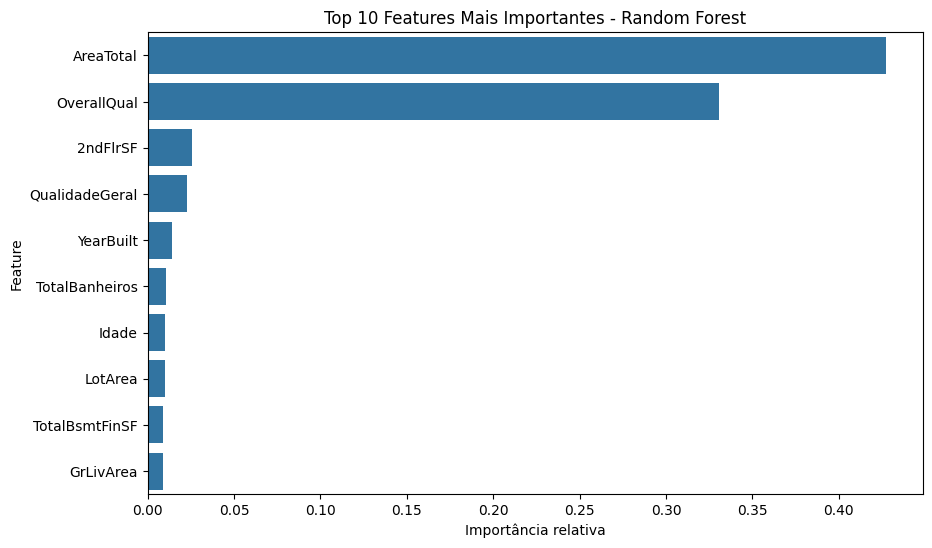

In [21]:
top10 = importancias.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x='Importancia',
    y='Feature'
)

plt.title(
    'Top 10 Features Mais Importantes - Random Forest'
)
plt.xlabel('Importância relativa')
plt.ylabel('Feature')

plt.show()